In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

print("✅ ¡Librerías cargadas con éxito en el entorno reproducible!")

✅ ¡Librerías cargadas con éxito en el entorno reproducible!


In [5]:
# 1. LEER EL ARCHIVO DE PACIENTES
df = pd.read_csv('datos_pacientes.csv')

# 2. AUDITORÍA INICIAL (Exigido en la rúbrica)
print("--- AUDITORÍA DE DATOS ---")
print(f"Número total de pacientes registrados: {df.shape[0]}")
print(f"Número total de columnas (Variables): {df.shape[1]}\n")

print("--- REVISIÓN DE VALORES NULOS/FALTANTES ---")
print(df.isnull().sum())

--- AUDITORÍA DE DATOS ---
Número total de pacientes registrados: 1000
Número total de columnas (Variables): 17

--- REVISIÓN DE VALORES NULOS/FALTANTES ---
Patient_ID                   0
Age                          0
Gender                       0
Weight_kg                    0
Height_cm                    0
BMI                          0
Chronic_Conditions         246
Drug_Allergies             324
Genetic_Disorders          339
Diagnosis                    0
Symptoms                     0
Recommended_Medication     263
Dosage                     195
Duration                   257
Treatment_Effectiveness      0
Adverse_Reactions            0
Recovery_Time_Days           0
dtype: int64


In [10]:
# Buscamos palabras clave comunes de reacciones que NO son graves
# Ajusta estas palabras según lo que leas en las filas de tu excel si es necesario
reacciones_leves = ['none', 'mild', 'no', 'dizziness', 'nausea']

df['Target_Adverse'] = df['Adverse_Reactions'].apply(
    lambda x: 0 if pd.isna(x) or str(x).lower().strip() in reacciones_leves else 1
)

print("Distribución corregida de la variable objetivo:")
print(df['Target_Adverse'].value_counts())

Distribución corregida de la variable objetivo:
Target_Adverse
1    506
0    494
Name: count, dtype: int64


C:\Users\aegon\AppData\Local\Temp\ipykernel_23436\2717868711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target_Adverse', palette='Set2')


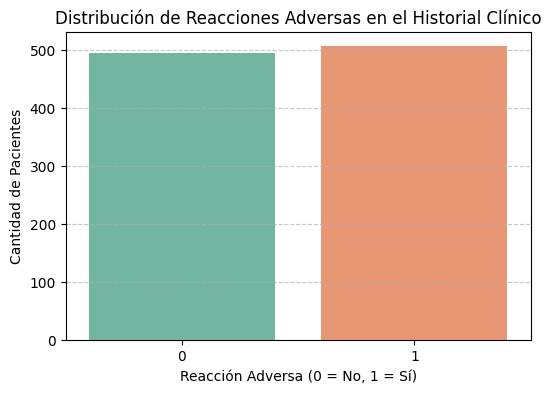

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Target_Adverse', palette='Set2')
plt.title('Distribución de Reacciones Adversas en el Historial Clínico')
plt.xlabel('Reacción Adversa (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
# ==============================================================================
# PASO 5 CORREGIDO: SEPARACIÓN DE DATOS Y MODELO BASELINE
# ==============================================================================

# 1. Seleccionamos los predictores (Features X) y el objetivo (Target Y)
X = df[['Age', 'BMI', 'Drug_Allergies']]
X = pd.get_dummies(X, drop_first=True) # Convierte textos a columnas binarias
y = df['Target_Adverse']

# --- TRUCO DE CONTROL DE ERRORES ---
# Forzamos a que X sea una matriz de números puros (float) y que 'y' sea un arreglo plano numérico
X = X.astype(float).values
y = y.astype(int).values

# 2. SEPARACIÓN DE DATOS (Validación rigurosa exigida en la rúbrica)
# Separación honesta 80% entrenamiento y 20% prueba para evitar data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. ENTRENAMIENTO DEL MODELO BASELINE (Piso técnico requerido)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. PREDICCIÓN Y REPORTES CLÍNICOS
y_pred = model.predict(X_test)

print("--- DESEMPEÑO DEL MODELO BASELINE ---")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred):.2f}\n")
print("Reporte de Clasificación Clínica:")
print(classification_report(y_test, y_pred))

--- DESEMPEÑO DEL MODELO BASELINE ---
Exactitud Global (Accuracy): 0.47

Reporte de Clasificación Clínica:
              precision    recall  f1-score   support

           0       0.46      0.40      0.43        99
           1       0.48      0.53      0.50       101

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.47      0.47       200

